<a href="https://colab.research.google.com/github/rohanbhangale/mldl_exps/blob/main/mldl_exp_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Dataset Preview:
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9  

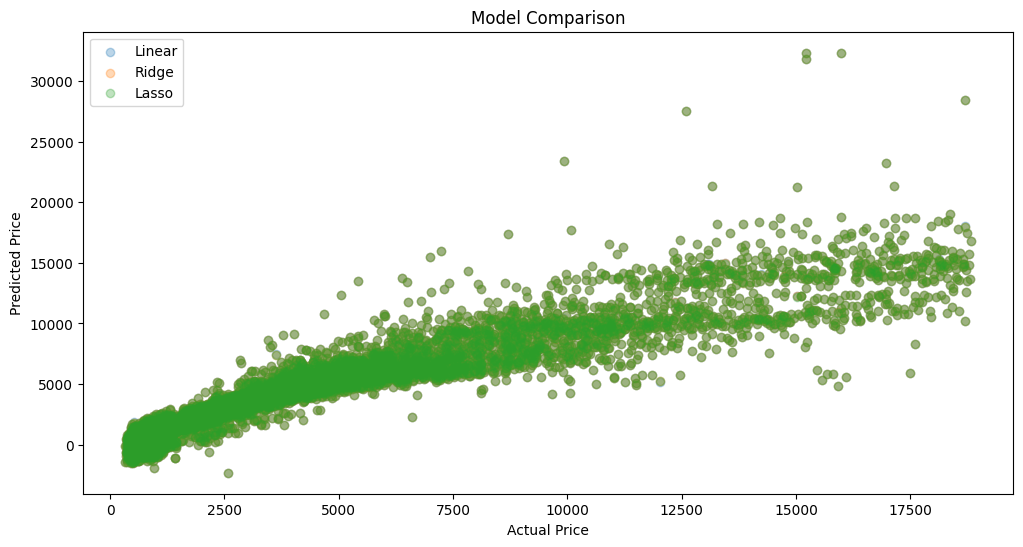


Feature Coefficients Comparison:
   Feature       Linear        Ridge        Lasso
0    carat  5203.339864  5200.081500  5198.981162
1      cut    73.928465    73.946643    73.883475
2    color  -456.442345  -456.353444  -456.252533
3  clarity   493.827821   493.850288   493.803001
4    depth  -222.365940  -222.119292  -221.611918
5    table  -210.442552  -210.424093  -210.322926
6        x -1310.868175 -1306.871118 -1300.686712
7        y    27.307125    26.974964    24.678863
8        z     8.619903     8.116841     5.150266


In [15]:
# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 2. Load Dataset
# ===============================
# Using built-in seaborn dataset
df = sns.load_dataset('diamonds')

print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ===============================
# 3. Data Preprocessing
# ===============================

# Encode categorical columns
le = LabelEncoder()

categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features (X) and Target (y)
X = df.drop('price', axis=1)
y = df['price']

# ===============================
# 4. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 5. Feature Scaling
# ===============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# 6. Multiple Linear Regression
# ===============================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# ===============================
# 7. Ridge Regression
# ===============================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

# ===============================
# 8. Lasso Regression
# ===============================
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

# ===============================
# 9. Evaluation Function
# ===============================
def evaluate_model(name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Results:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R2 Score: {r2:.4f}")

# ===============================
# 10. Evaluate All Models
# ===============================
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)
evaluate_model("Lasso Regression", y_test, y_pred_lasso)

# ===============================
# 11. Visualization
# ===============================

plt.figure(figsize=(12,6))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='Linear')
plt.scatter(y_test, y_pred_ridge, alpha=0.3, label='Ridge')
plt.scatter(y_test, y_pred_lasso, alpha=0.3, label='Lasso')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Model Comparison")
plt.legend()

plt.show()

# ===============================
# 12. Coefficient Comparison
# ===============================

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print("\nFeature Coefficients Comparison:")
print(coeff_df)

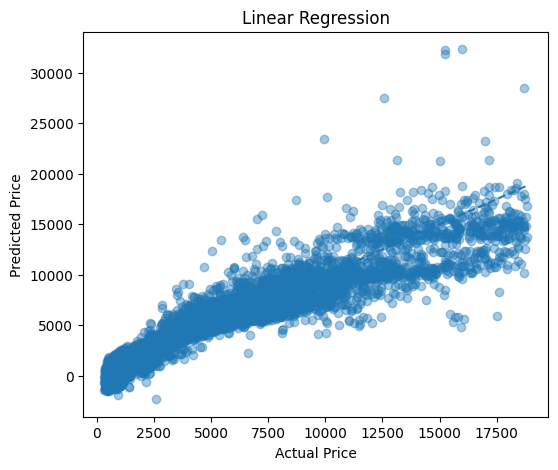

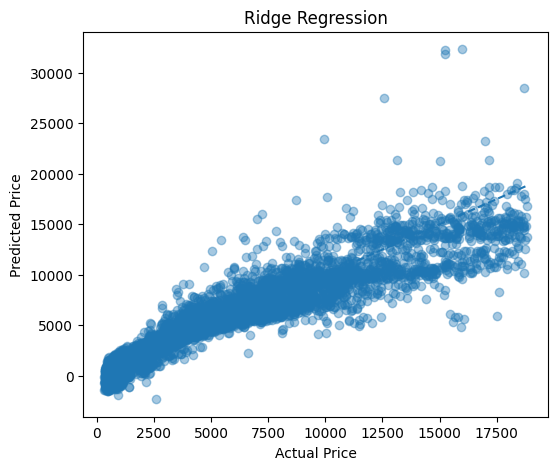

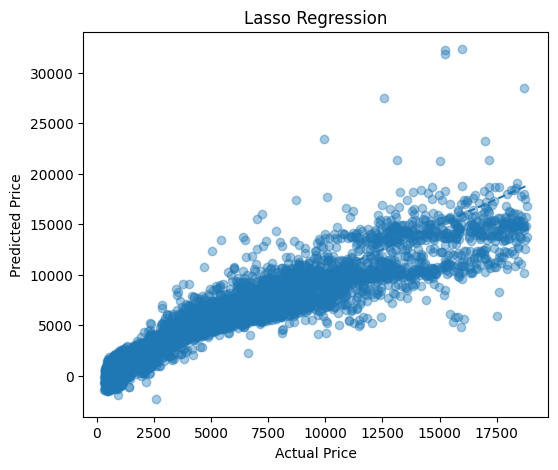

In [16]:
# Function to plot with perfect line
def plot_graph(y_test, y_pred, title):
    plt.figure(figsize=(6,5))
    plt.scatter(y_test, y_pred, alpha=0.4)

    # Perfect prediction line
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             linestyle='--')

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(title)
    plt.show()


# Call function
plot_graph(y_test, y_pred_lr, "Linear Regression")
plot_graph(y_test, y_pred_ridge, "Ridge Regression")
plot_graph(y_test, y_pred_lasso, "Lasso Regression")